In [23]:
# Pandas for managing datasets
import pandas as pd

In [24]:
# Matplotlib for additional customization
from matplotlib import pyplot as plt
%matplotlib inline
# Seaborn for plotting and styling
import seaborn as sns

In [25]:
!wget -q https://elitedatascience.com/wp-content/uploads/2022/07/Pokemon.csv
# Read dataset
df = pd.read_csv('Pokemon.csv', index_col=0, encoding='latin')

In [26]:

# Display first 5 observations
df.head()

,Name,Type 1,Type 2,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Stage,Legendary
#,,,,,,,,,,,,
1,Bulbasaur,Grass,Poison,318,45,49,49,65,65,45,1,False
2,Ivysaur,Grass,Poison,405,60,62,63,80,80,60,2,False
3,Venusaur,Grass,Poison,525,80,82,83,100,100,80,3,False
4,Charmander,Fire,NaN,309,39,52,43,60,50,65,1,False
5,Charmeleon,Fire,NaN,405,58,64,58,80,65,80,2,False


Scatter Plot

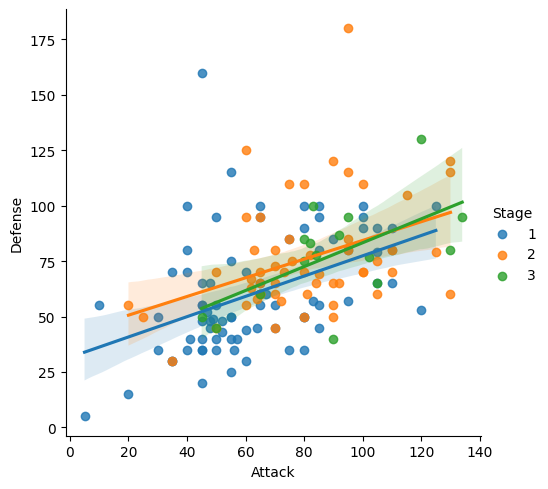

In [27]:

# Scatterplot arguments
sns.lmplot(x='Attack', y='Defense', data=df,
           fit_reg=True, # No regression line
           hue='Stage')   # Color by evolution stage

Box Plots

<Axes: >

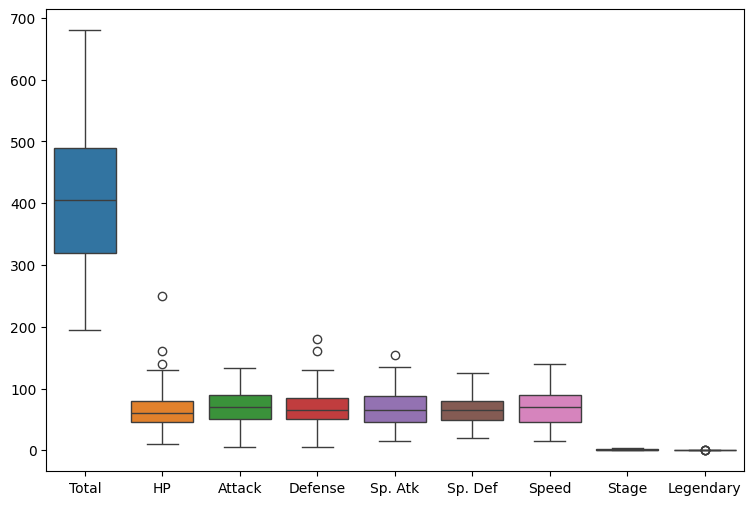

In [28]:
# Boxplot
plt.figure(figsize=(9,6)) # Set plot dimensions
sns.boxplot(data=df)

<Axes: >

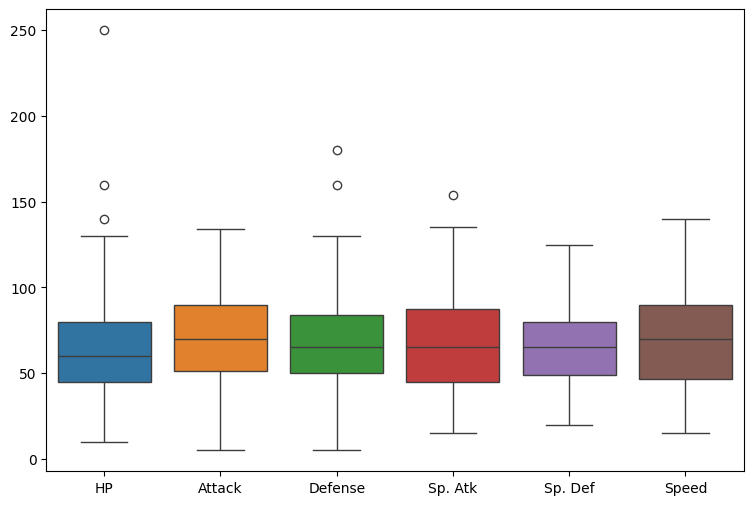

In [29]:

# Preprocess DataFrame
stats_df = df.drop(['Total', 'Stage', 'Legendary'], axis=1)

# New boxplot using stats_df
plt.figure(figsize=(9,6)) # Set plot dimensions
sns.boxplot(data=stats_df)

Violin Plot

<Axes: xlabel='Type 1', ylabel='Attack'>

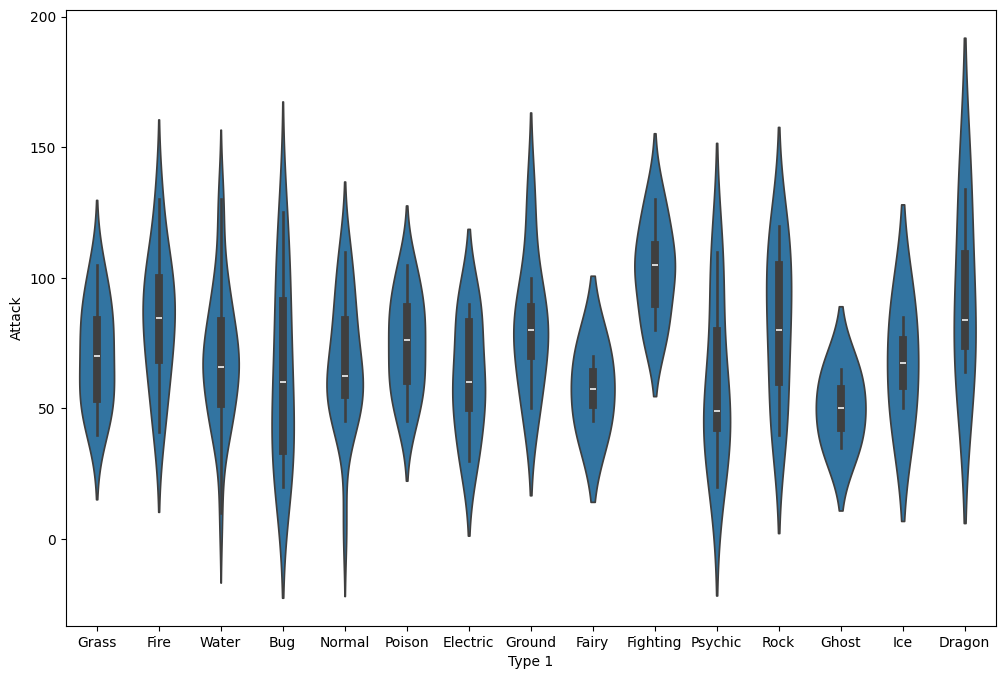

In [30]:
# Violin plot
plt.figure(figsize=(12,8)) # Set plot dimensions
sns.violinplot(x='Type 1', y='Attack', data=df)

In [31]:
stats_df.head()

,Name,Type 1,Type 2,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed
#,,,,,,,,,
1,Bulbasaur,Grass,Poison,45,49,49,65,65,45
2,Ivysaur,Grass,Poison,60,62,63,80,80,60
3,Venusaur,Grass,Poison,80,82,83,100,100,80
4,Charmander,Fire,NaN,39,52,43,60,50,65
5,Charmeleon,Fire,NaN,58,64,58,80,65,80


Heat Map

In [32]:
import numpy as np
# Calculate correlations
# Select only numeric columns for correlation calculation
numeric_cols = ['HP', 'Attack', 'Defense', 'Sp. Atk', 'Sp. Def', 'Speed']
pokemon_features = stats_df[numeric_cols]

corr = pokemon_features.corr()

<Axes: >

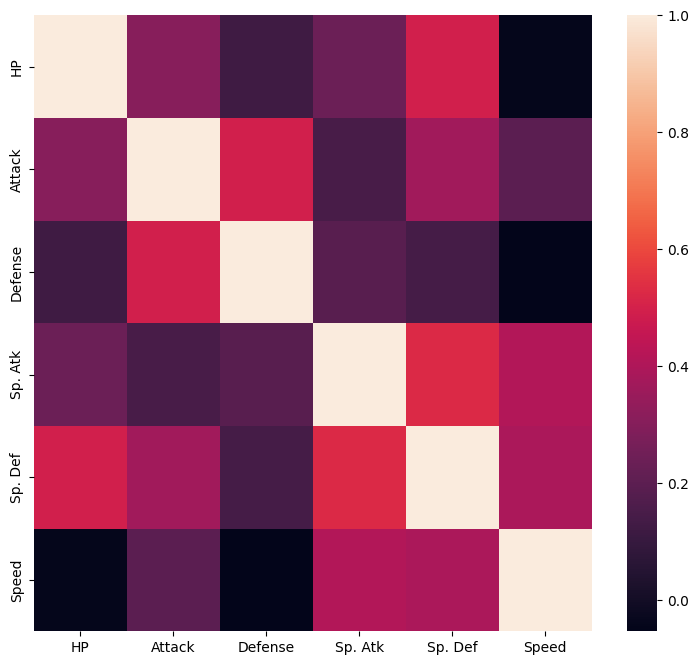

In [33]:
# Heatmap
plt.figure(figsize=(9,8))
sns.heatmap(corr)

# What is correlation
this measure how stringly two variables are connected

ex: if A increase when B increase -> positive correlation

  if A decrease when B decrease -> negative crrelation
  

**Correlation Values**

+1 - perfect positive realtionship

0 - no relationship

-1 - perfect negative relationship



## Pearson
Do these two variables have a linear (straight-line) relationship

pearson correlation is close to +1

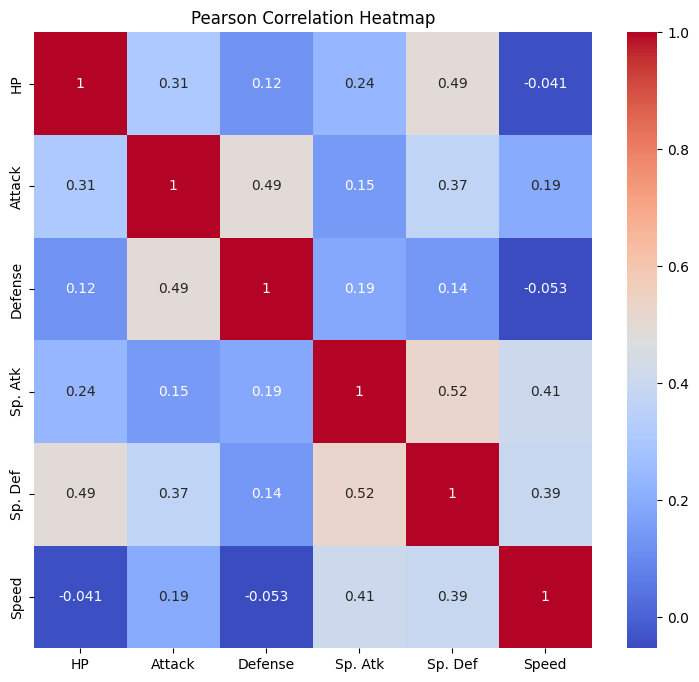

In [34]:
pearson_corr = pokemon_features.corr(method='pearson')

plt.figure(figsize=(9,8))
sns.heatmap(pearson_corr, annot=True, cmap="coolwarm")

plt.title("Pearson Correlation Heatmap")
plt.show()

## Spearman

Even if the values don't increase in a straight line, do they at least increase in the same order?

Pearson may not be very high because the relationship isn't linear.
Spearman will still be very high because the order is perfectly increasing.

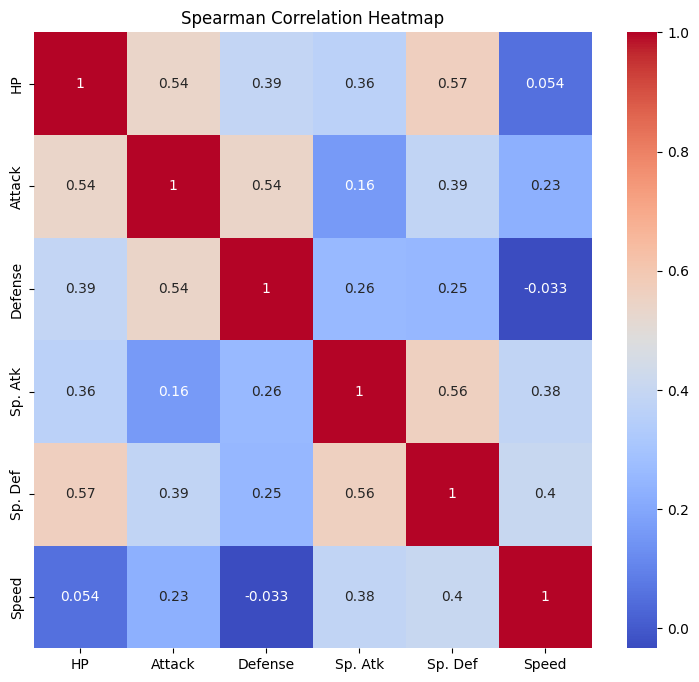

In [35]:
spearman_corr = pokemon_features.corr(method='spearman')

plt.figure(figsize=(9,8))
sns.heatmap(spearman_corr, annot=True, cmap="coolwarm")

plt.title("Spearman Correlation Heatmap")
plt.show()